## Imports's

In [1]:
# Basic tools
import numpy as np
import matplotlib.pyplot as plt
import random

# Deep Learning
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers,Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


## Load The Data

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Show the shapes
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


## Explore the MNIST Dataset

In [3]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

Text(0.5, 1.0, 'Label: 0')

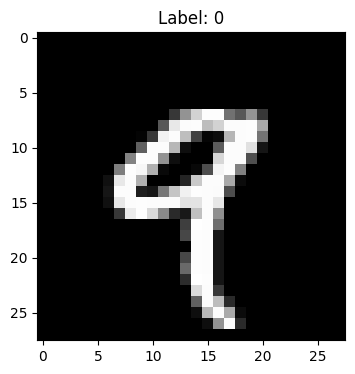

In [4]:
plt.figure(figsize=(4,4))
plt.imshow(x_train[4],cmap='grey')
plt.title(f"Label: {y_train[1]}") # print any one idx


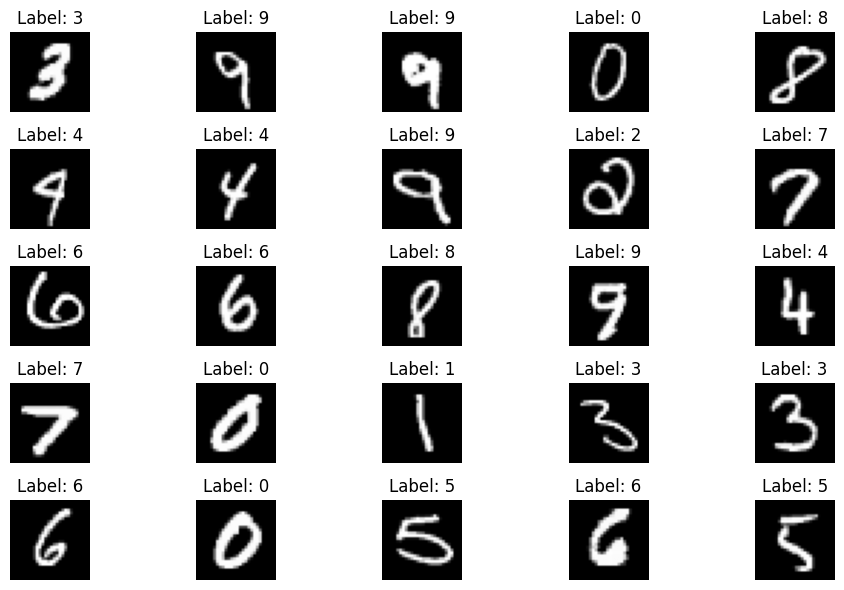

In [5]:
plt.figure(figsize=(10,6))

for i in range(25):
  idx = random.randint(0,len(x_train)-1)
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[idx],cmap='grey')
  plt.title(f"Label: {y_train[idx]}")
  plt.axis('off')
plt.tight_layout()
plt.show()

## Check Class Balance

/tmp/ipython-input-1183151604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="mako")


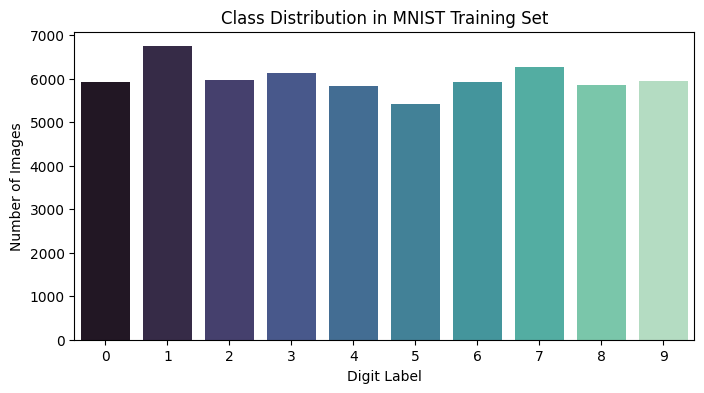

In [6]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8,4))
sns.barplot(x=unique, y=counts, palette="mako")
plt.title("Class Distribution in MNIST Training Set")
plt.xlabel("Digit Label")
plt.ylabel("Number of Images")
plt.show()

## Preprocessing the data

To See pixel values

In [7]:
print("Pixel values:\n")
print(x_train[4].reshape(28, 28))

Pixel values:

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  55 148 210 253 253 113
   87 148  55   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  87

In [8]:
# Normalizing the pixels for Neural Networks

x_train = x_train / 255.0
x_test  = x_test / 255.0

## Neural Network

(batch, height, width, channels)


when you write -1 in reshape, it means:

“Automatically calculate this dimension for me.”

In [9]:
x_train = x_train.reshape(-1, 28, 28, 1)


| Situation                                                                                      | Preferred Layer                         | Why                                                             |
| ---------------------------------------------------------------------------------------------- | --------------------------------------- | --------------------------------------------------------------- |
| 🧩 **Small, simple dataset** (like MNIST, Fashion-MNIST)                                       | ✅ **Flatten()**                         | Keeps full detail, helps small models learn fine pixel patterns |
| 🏞️ **Large / real-world images** (Cats vs Dogs, CIFAR, Flowers, Medical images)               | ✅ **GlobalAveragePooling2D()**          | More stable, fewer parameters, less overfitting                 |
| 🧪 **Transfer learning / pretrained models (ResNet, MobileNet)**                               | ✅ **GlobalAveragePooling2D()**          | It’s the standard in modern architectures                       |
| 🧰 **Custom / experimental models** where spatial detail matters (e.g. segmentation, heatmaps) | ✅ **Flatten()** or **Conv → Flatten()** | You need spatial info preserved                                 |


In [10]:
inputs = Input(shape=(28, 28, 1))

x = layers.Conv2D(32,(3,3),activation='relu')(inputs)
x = layers.MaxPool2D()(x)

x = layers.Conv2D(32,(3,3), activation='relu')(x)
x = layers.MaxPool2D()(x)

x = layers.Conv2D(128,(3,3), activation='relu')(x)
x = layers.MaxPool2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,466 (216.66 KB)

 Trainable params: 55,466 (216.66 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Model Checkpoint to save the best model during training
model_checkpoint = ModelCheckpoint('best_mnist_model.keras', monitor='val_loss', save_best_only=True)

callbacks_list = [early_stopping, model_checkpoint]

In [12]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7750 - loss: 0.6940 - val_accuracy: 0.9738 - val_loss: 0.0936
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9610 - loss: 0.1311 - val_accuracy: 0.9813 - val_loss: 0.0585
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9708 - loss: 0.0968 - val_accuracy: 0.9830 - val_loss: 0.0606
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9781 - loss: 0.0710 - val_accuracy: 0.9842 - val_loss: 0.0506
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9823 - loss: 0.0598 - val_accuracy: 0.9843 - val_loss: 0.0517
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9841 - loss: 0.0517 - val_accuracy: 0.9862 - val_loss: 0.0447
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9873 - loss: 0.0418 - val_accuracy: 0.9865 - val_loss: 0.0511
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9885 - loss: 0.0374 - val_accuracy: 0

## Results

In [14]:
# Reshape x_test to include the channel dimension
x_test = x_test.reshape(-1, 28, 28, 1)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

# Print the test accuracy and loss
print(f"Test Accuracy: {test_acc:.4%} | Test Loss: {test_loss:.4f}")

Test Accuracy: 98.6400% | Test Loss: 0.0508


### Learning curves

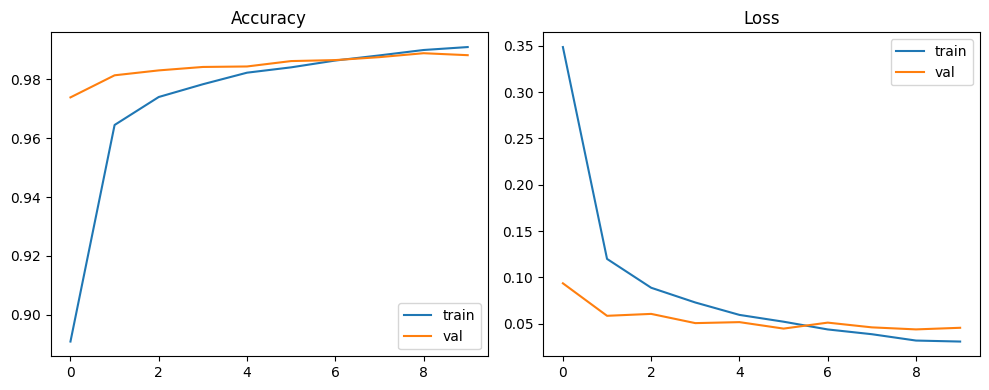

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()
